In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [4]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 2/16 photon absorption

In [5]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

In [6]:
import os

In [7]:
header = "D:/K_sunada/result/CDY155/"
dirlist_0 = os.listdir(header + '/2024-02-18/')[69:78]
dirlist_1 = os.listdir(header + '/2024-02-19/')[27:36]
dirlist_2 = os.listdir(header + '/2024-02-18/')[54:63]
dirlist_3 = os.listdir(header + '/2024-02-19/')[36:45]
dirlist_4 = os.listdir(header + '/2024-02-19/')[3:12]


In [8]:
dirlist_3

['2024-02-19T121547_2cd3dcf7-78_JPA_ab_waveform_qstate_repeat',
 '2024-02-19T121917_aa51c2bb-78_JPA_ab_waveform_qstate_repeat',
 '2024-02-19T122247_27b3dfc1-78_JPA_ab_waveform_qstate_repeat',
 '2024-02-19T122620_a6886455-78_JPA_ab_waveform_qstate_repeat',
 '2024-02-19T122953_25738db0-78_JPA_ab_waveform_qstate_repeat',
 '2024-02-19T123326_a464e99b-78_JPA_ab_waveform_qstate_repeat',
 '2024-02-19T123700_23a200cb-78_JPA_ab_waveform_qstate_repeat',
 '2024-02-19T124033_a31aa0b7-78_JPA_ab_waveform_qstate_repeat',
 '2024-02-19T124407_22abfa2b-78_JPA_ab_waveform_qstate_repeat']

[98.75467969]


<Figure size 800x300 with 0 Axes>

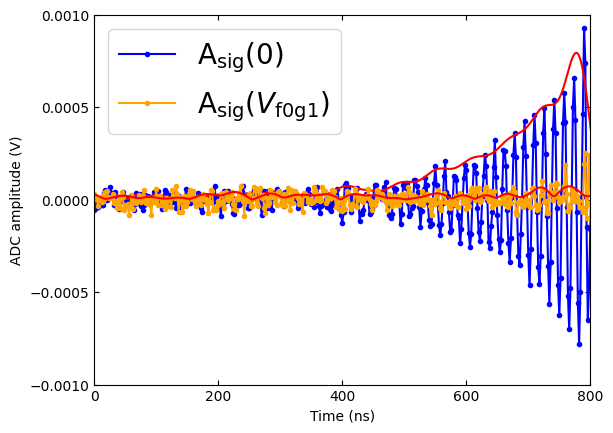

In [9]:
## absorption rate
ph_amp = 0
fogi_freq = 0
###############################################
data = dirlist_0[0]
num_of_ph_amp = 5
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header+ '/2024-02-18/', data,num_of_ph_amp, num_of_fogi_freq, 62.5e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.001, 0.001)
ax0.set_xlim(0, 800)
plt.legend()
print(d[5][ph_amp])
# plt.tight_layout()
# plt.savefig('waveform_003_mi20.png', bbox_inches='tight')
# plt.show()

[98.89378628]


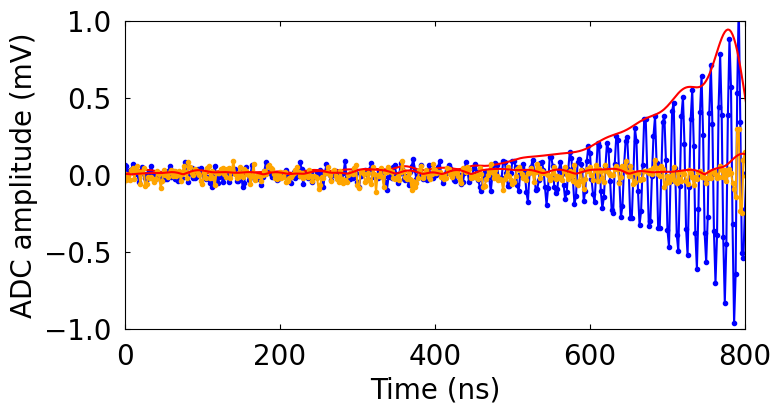

In [10]:
## absorption rate
ph_amp = 0
fogi_freq = 0
###############################################
data = dirlist_2[0]
num_of_ph_amp = 5
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header+ '/2024-02-18/', data,num_of_ph_amp, num_of_fogi_freq, 82.5e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig, (ax0) = plt.subplots(figsize=(8, 4),nrows=1)
plt.rcParams["font.size"] = 24
plt.rcParams["xtick.major.size"] = 8
plt.rcParams["ytick.major.size"] = 8
plt.tick_params(pad = 10, top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (mV)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq]*1e3, '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq]*1e3, color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq]*1e3, '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq]*1e3, color='red')
ax0.set_ylim(-1, 1)
ax0.set_xlim(0, 800)
# plt.legend()
print(d[5][ph_amp])
# plt.tight_layout()
# plt.savefig('waveform_003_0_1.png', bbox_inches='tight')
# plt.show()

[98.1958538]


<Figure size 800x300 with 0 Axes>

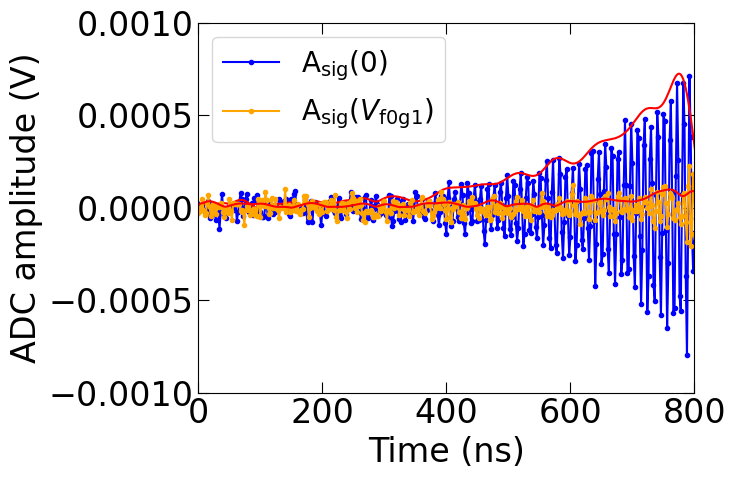

In [11]:
## absorption rate
ph_amp = 0
fogi_freq = 0
###############################################
data = dirlist_4[0]
num_of_ph_amp = 5
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header+ '/2024-02-19/', data,num_of_ph_amp, num_of_fogi_freq, 95e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.001, 0.001)
ax0.set_xlim(0, 800)
plt.legend()
print(d[5][ph_amp])
# plt.tight_layout()
# plt.savefig('waveform_003_20.png', bbox_inches='tight')
# plt.show()

In [12]:
##id = 0
header = "D:/K_sunada/result/CDY155/"
rate_003 = []
rate_01 = []
rate_02 = []
rate_03 = []
rate_04 = []
for i in range(len(dirlist_0)):
    data = dirlist_0[i]
    num_of_ph_amp = 5
    num_of_fogi_freq = 1
    ###############################################
    d = data_acquisition_env_ene(header+'/2024-02-18/', data,num_of_ph_amp, num_of_fogi_freq, 82.5e6)
    rate_003_temp = d[5][0][0]
    rate_01_temp = d[5][1][0]
    rate_02_temp = d[5][2][0]
    rate_03_temp = d[5][3][0]
    rate_04_temp = d[5][4][0]
    rate_003.append(rate_003_temp)
    rate_01.append(rate_01_temp)
    rate_02.append(rate_02_temp)
    rate_03.append(rate_03_temp)
    rate_04.append(rate_04_temp)

rates_0 = np.array([rate_003, rate_01, rate_02, rate_03, rate_04])

In [13]:
##id = 1
header = "D:/K_sunada/result/CDY155/"
rate_003 = []
rate_01 = []
rate_02 = []
rate_03 = []
rate_04 = []
for i in range(len(dirlist_1)):
    data = dirlist_1[i]
    num_of_ph_amp = 5
    num_of_fogi_freq = 1
    ###############################################
    d = data_acquisition_env_ene(header+'/2024-02-19/', data,num_of_ph_amp, num_of_fogi_freq, 82.5e6)
    rate_003_temp = d[5][0][0]
    rate_01_temp = d[5][1][0]
    rate_02_temp = d[5][2][0]
    rate_03_temp = d[5][3][0]
    rate_04_temp = d[5][4][0]
    rate_003.append(rate_003_temp)
    rate_01.append(rate_01_temp)
    rate_02.append(rate_02_temp)
    rate_03.append(rate_03_temp)
    rate_04.append(rate_04_temp)

rates_1 = np.array([rate_003, rate_01, rate_02, rate_03, rate_04])

In [14]:
##id = 2
header = "D:/K_sunada/result/CDY155/"
rate_003 = []
rate_01 = []
rate_02 = []
rate_03 = []
rate_04 = []
for i in range(len(dirlist_2)):
    data = dirlist_2[i]
    num_of_ph_amp = 5
    num_of_fogi_freq = 1
    ###############################################
    d = data_acquisition_env_ene(header+'/2024-02-18/', data,num_of_ph_amp, num_of_fogi_freq, 82.5e6)
    rate_003_temp = d[5][0][0]
    rate_01_temp = d[5][1][0]
    rate_02_temp = d[5][2][0]
    rate_03_temp = d[5][3][0]
    rate_04_temp = d[5][4][0]
    rate_003.append(rate_003_temp)
    rate_01.append(rate_01_temp)
    rate_02.append(rate_02_temp)
    rate_03.append(rate_03_temp)
    rate_04.append(rate_04_temp)

rates_2 = np.array([rate_003, rate_01, rate_02, rate_03, rate_04])

In [15]:
##id = 3
header = "D:/K_sunada/result/CDY155/"
rate_003 = []
rate_01 = []
rate_02 = []
rate_03 = []
rate_04 = []
for i in range(len(dirlist_3)):
    data = dirlist_3[i]
    num_of_ph_amp = 5
    num_of_fogi_freq = 1
    ###############################################
    d = data_acquisition_env_ene(header+'/2024-02-19/', data,num_of_ph_amp, num_of_fogi_freq, 90e6)
    rate_003_temp = d[5][0][0]
    rate_01_temp = d[5][1][0]
    rate_02_temp = d[5][2][0]
    rate_03_temp = d[5][3][0]
    rate_04_temp = d[5][4][0]
    rate_003.append(rate_003_temp)
    rate_01.append(rate_01_temp)
    rate_02.append(rate_02_temp)
    rate_03.append(rate_03_temp)
    rate_04.append(rate_04_temp)

rates_3 = np.array([rate_003, rate_01, rate_02, rate_03, rate_04])

In [16]:
##id = 4
header = "D:/K_sunada/result/CDY155/"
rate_003 = []
rate_01 = []
rate_02 = []
rate_03 = []
rate_04 = []
for i in range(len(dirlist_4)):
    data = dirlist_4[i]
    num_of_ph_amp = 5
    num_of_fogi_freq = 1
    ###############################################
    d = data_acquisition_env_ene(header+'/2024-02-19/', data,num_of_ph_amp, num_of_fogi_freq, 95e6)
    rate_003_temp = d[5][0][0]
    rate_01_temp = d[5][1][0]
    rate_02_temp = d[5][2][0]
    rate_03_temp = d[5][3][0]
    rate_04_temp = d[5][4][0]
    rate_003.append(rate_003_temp)
    rate_01.append(rate_01_temp)
    rate_02.append(rate_02_temp)
    rate_03.append(rate_03_temp)
    rate_04.append(rate_04_temp)

rates_4 = np.array([rate_003, rate_01, rate_02, rate_03, rate_04])

In [17]:
def error_bar(rate):
    rate_mean = np.mean(rate)
    rate_se = np.array(np.std(rate))
    return rate_mean, rate_se

In [18]:
tr_data_m = []
tr_data_s = []
for i in range(len(rates_0)):
    rate_mean = error_bar(rates_0[i])[0]
    rate_se = error_bar(rates_0[i])[1]
    tr_data_m.append(rate_mean)
    tr_data_s.append(rate_se)
data_0 = [tr_data_m, tr_data_s]

In [19]:
tr_data_m = []
tr_data_s = []
for i in range(len(rates_1)):
    rate_mean = error_bar(rates_1[i])[0]
    rate_se = error_bar(rates_1[i])[1]
    tr_data_m.append(rate_mean)
    tr_data_s.append(rate_se)
data_1 = [tr_data_m, tr_data_s]

In [20]:
tr_data_m = []
tr_data_s = []
for i in range(len(rates_2)):
    rate_mean = error_bar(rates_2[i])[0]
    rate_se = error_bar(rates_2[i])[1]
    tr_data_m.append(rate_mean)
    tr_data_s.append(rate_se)
data_2 = [tr_data_m, tr_data_s]

In [21]:
tr_data_m = []
tr_data_s = []
for i in range(len(rates_3)):
    rate_mean = error_bar(rates_3[i])[0]
    rate_se = error_bar(rates_3[i])[1]
    tr_data_m.append(rate_mean)
    tr_data_s.append(rate_se)
data_3 = [tr_data_m, tr_data_s]

In [22]:
tr_data_m = []
tr_data_s = []
for i in range(len(rates_4)):
    rate_mean = error_bar(rates_4[i])[0]
    rate_se = error_bar(rates_4[i])[1]
    tr_data_m.append(rate_mean)
    tr_data_s.append(rate_se)
data_4 = [tr_data_m, tr_data_s]

[94.79218376681325, 94.86638560919704, 89.67766831702846, 82.96962259746653, 76.5689227904107]


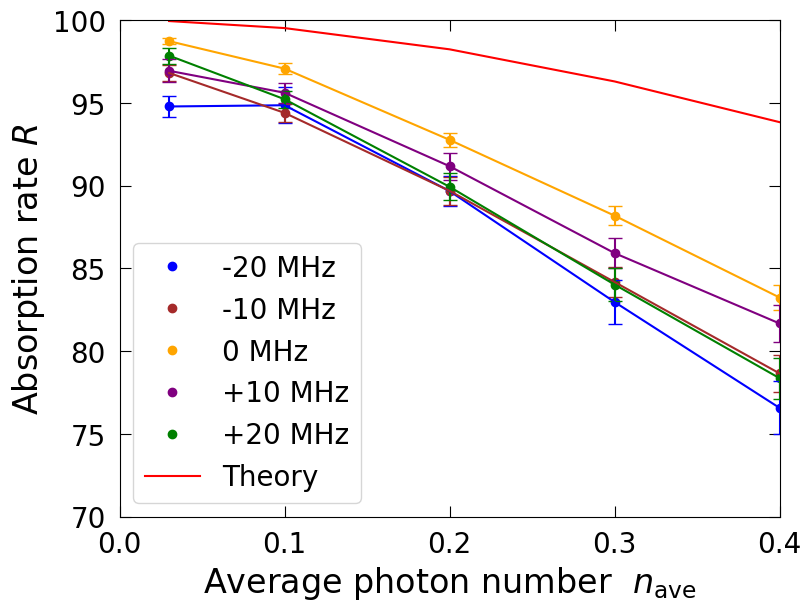

In [23]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(pad = 10,top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

ph_num = np.array([0.03, 0.1, 0.2, 0.3, 0.4])
ax.plot(ph_num, data_0[0], 'o', color='blue', label = "-20 MHz")
ax.plot(ph_num, data_1[0], 'o', color='brown', label = "-10 MHz")
ax.plot(ph_num, data_2[0], 'o', color='orange', label = "0 MHz")
ax.plot(ph_num, data_3[0], 'o', color='purple', label = "+10 MHz")
ax.plot(ph_num, data_4[0], 'o', color='green', label = "+20 MHz")
x = np.array([0.03, 0.1, 0.2, 0.3, 0.4])
ax.plot(x, np.exp(-x)*(1+x)*100, label="Theory", color = "red")
# ax.plot(ph_num, utr_data[0], 'o', color='orange')
# ax.plot(ph_num, sq_data[0], 'o',color='green')
# ax.plot(ph_num, 1-np.exp(-ph_num)*(ph_num+ph_num**2))
ax.errorbar(ph_num, data_0[0], yerr=data_0[1],  capsize=5,  color='blue')
ax.errorbar(ph_num, data_1[0], yerr=data_1[1],  capsize=5, color='brown')
ax.errorbar(ph_num, data_2[0], yerr=data_2[1],  capsize=5, color='orange')
ax.errorbar(ph_num, data_3[0], yerr=data_3[1],  capsize=5, color='purple')
ax.errorbar(ph_num, data_4[0], yerr=data_4[1],  capsize=5, color='green')
# ax.errorbar(ph_num, utr_data[0], yerr=utr_data[1], capsize=5, label="Decaying exponential pulse",color='orange')
# ax.errorbar(ph_num, sq_data[0], yerr=sq_data[1],  capsize=5, label="Square pulse", color='green')
ax.set_xlabel('Average photon number  $n_{\mathrm{ave}}$', size='large')
ax.set_ylabel('Absorption rate $R$', size='large')
plt.legend()
plt.ylim(70, 100)
plt.xlim(0, 0.4)
print(data_0[0])
# plt.savefig('abs_rate_summary_defence1.png', bbox_inches='tight')


[94.79218376681325, 94.86638560919704, 89.67766831702846, 82.96962259746653, 76.5689227904107]


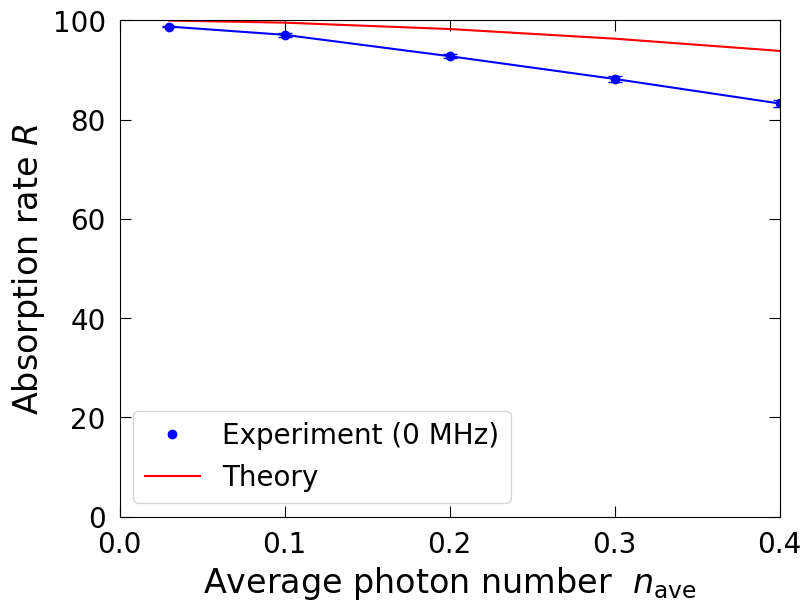

In [24]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(pad = 10,top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

ph_num = np.array([0.03, 0.1, 0.2, 0.3, 0.4])
# ax.plot(ph_num, data_0[0], 'o', color='blue', label = "-20 MHz")
# ax.plot(ph_num, data_1[0], 'o', color='brown', label = "-10 MHz")
ax.plot(ph_num, data_2[0], 'o', color='blue', label = "Experiment (0 MHz)")
# ax.plot(ph_num, data_3[0], 'o', color='purple', label = "+10 MHz")
# ax.plot(ph_num, data_4[0], 'o', color='green', label = "+20 MHz")
x = np.array([0.03, 0.1, 0.2, 0.3, 0.4])
ax.plot(x, np.exp(-x)*(1+x)*100, label="Theory", color = "red")
# ax.plot(ph_num, utr_data[0], 'o', color='orange')
# ax.plot(ph_num, sq_data[0], 'o',color='green')
# ax.plot(ph_num, 1-np.exp(-ph_num)*(ph_num+ph_num**2))
# ax.errorbar(ph_num, data_0[0], yerr=data_0[1],  capsize=5,  color='blue')
# ax.errorbar(ph_num, data_1[0], yerr=data_1[1],  capsize=5, color='brown')
ax.errorbar(ph_num, data_2[0], yerr=data_2[1],  capsize=5, color='blue')
# ax.errorbar(ph_num, data_3[0], yerr=data_3[1],  capsize=5, color='purple')
# ax.errorbar(ph_num, data_4[0], yerr=data_4[1],  capsize=5, color='green')
# ax.errorbar(ph_num, utr_data[0], yerr=utr_data[1], capsize=5, label="Decaying exponential pulse",color='orange')
# ax.errorbar(ph_num, sq_data[0], yerr=sq_data[1],  capsize=5, label="Square pulse", color='green')
ax.set_xlabel('Average photon number  $n_{\mathrm{ave}}$', size='large')
ax.set_ylabel('Absorption rate $R$', size='large')
plt.legend()
plt.ylim(0, 100)
plt.xlim(0, 0.4)
print(data_0[0])
# plt.savefig('abs_rate_summary_defence1.png', bbox_inches='tight')


[98.74150996746852, 97.07913943546902, 92.77445065983206, 88.19078404595653, 83.24286869089516]


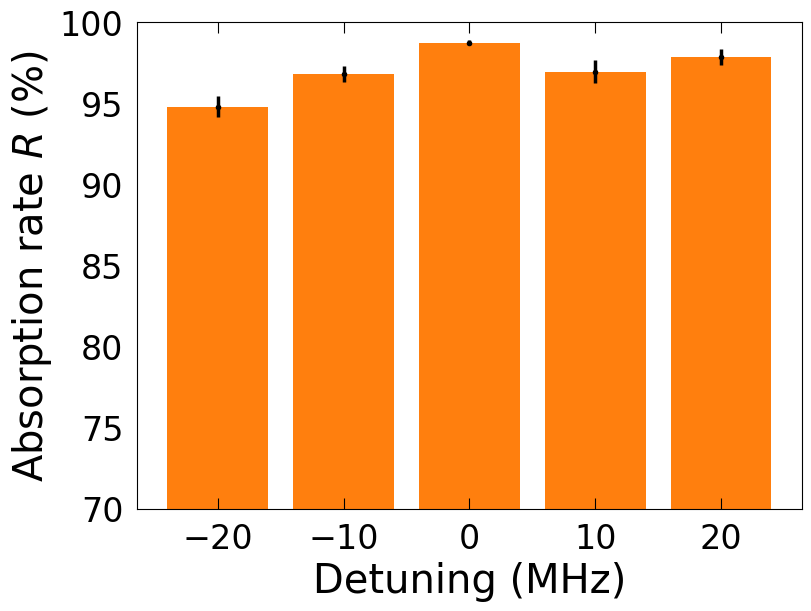

In [35]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 24
# plt.title("Rabi(amp)")
plt.tick_params(pad = 10,top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["xtick.major.size"] = 8
plt.rcParams["ytick.major.size"] = 0


x = np.array([-20, -10, 0, 10, 20])
data003 = np.array([data_0[0][0], data_1[0][0], data_2[0][0], data_3[0][0], data_4[0][0]])
err003 = np.array([data_0[1][0], data_1[1][0], data_2[1][0], data_3[1][0], data_4[1][0]])
data01 = np.array([data_0[0][1], data_1[0][1], data_2[0][1], data_3[0][1], data_4[0][1]])
err01 = np.array([data_0[1][1], data_1[1][1], data_2[1][1], data_3[1][1], data_4[1][1]])
data02 = np.array([data_0[0][2], data_1[0][2], data_2[0][2], data_3[0][2], data_4[0][2]])
err02 = np.array([data_0[1][2], data_1[1][2], data_2[1][2], data_3[1][2], data_4[1][2]])
data03 = np.array([data_0[0][3], data_1[0][3], data_2[0][3], data_3[0][3], data_4[0][3]])
err03 = np.array([data_0[1][3], data_1[1][3], data_2[1][3], data_3[1][3], data_4[1][3]])
data04 = np.array([data_0[0][4], data_1[0][4], data_2[0][4], data_3[0][4], data_4[0][4]])
err04 = np.array([data_0[1][4], data_1[1][4], data_2[1][4], data_3[1][4], data_4[1][4]])

ph_num = np.array([0.03, 0.1, 0.2, 0.3, 0.4])
ax.errorbar(x, data003, yerr=err003,fmt='.',elinewidth=2.5, capsize=0,  color='black', label="$n_{\mathrm{ave}}=0.03$")
plt.bar(x, data003, width=8, color="tab:orange")#, bottom=None, hold=None,
#data=None, **kwargs)
# ax.errorbar(x, data01, yerr=err01,  capsize=5,  color='orange', label="$n_{\mathrm{ave}}=0.1$")
# ax.errorbar(x, data02, yerr=err02,  capsize=5,  color='green', label="$n_{\mathrm{ave}}=0.2$")
# ax.errorbar(x, data03, yerr=err03,  capsize=5,  color='purple', label="$n_{\mathrm{ave}}=0.3$")
# ax.errorbar(x, data04, yerr=err04,  capsize=5,  color='brown', label="$n_{\mathrm{ave}}=0.4$")


# ax.errorbar(ph_num, utr_data[0], yerr=utr_data[1], capsize=5, label="Decaying exponential pulse",color='orange')
# ax.errorbar(ph_num, sq_data[0], yerr=sq_data[1],  capsize=5, label="Square pulse", color='green')
ax.set_xlabel('Detuning (MHz)', size='large')
ax.set_ylabel('Absorption rate $R$ (%)', size='large')
# plt.legend(ncol=2)
plt.ylim(70, 100)
# plt.xlim(0, 0.4)
print(data_2[0])
plt.savefig('R_detuning003.png', bbox_inches='tight')


In [36]:
def square(freq, amp, duration):
    x = np.linspace(0, duration-1, duration)
    y = amp* np.cos(2*np.pi* freq*(x*1e-9))
    env = np.zeros(duration) + amp
    return y, env

In [37]:
# square simulation
id = 4
amp_id = 7
sample_rate = 2e-9
ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
x = np.linspace(0, 499, 500)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
tr_waveform_if = (y_env*np.cos(2*np.pi* ph_if[id]*(x*1e-9)))[::-1]*tr_amp[amp_id] * abs_rate[amp_id]
tr_waveform = (y_env)[::-1]*tr_amp[amp_id]
tr_waveform_abs = tr_waveform * abs_rate[amp_id] ## abs limit
fig, ax = plt.subplots(figsize=(8,4),constrained_layout=True)
sq_waveform_if = np.array(square(ph_if[4], 0.05, 500)[0] )*sq_amp[amp_id]
sq_waveform = np.array(square(ph_if[4], 0.05, 500)[1] )*sq_amp[amp_id]

ene_org = 0
for t in range(int(len(x)/sample_rate*1e-9)+1):
    y = sq_waveform[2*t]
    ene_org = ene_org + (y**2)*sample_rate

ys = []
ene_abs = 0
for t in range(int(len(x)/sample_rate*1e-9)+1):
    if tr_waveform_abs[2*t]<sq_waveform[2*t]:
        y = tr_waveform_abs[2*t]
        ys.append(y)
    else:
        y = sq_waveform[2*t]
        ys.append(y)
    ene_abs = ene_abs + (y**2)*sample_rate

# plt.plot(x, tr_waveform)
plt.plot(x, tr_waveform_if)
plt.plot(x, sq_waveform_if)
plt.plot(np.linspace(0, 498, 250), ys)
print(ene_org, ene_abs, ene_abs/ene_org*1e2)

NameError: name 'tr_amp' is not defined

In [ ]:
sim_sq_rate = [64.36, 63.31, 61.58, 59.70, 57.68, 54.93, 53.09, 51.55]

6.904314684780152e-09 7.507707125106972e-10 10.87393531128721


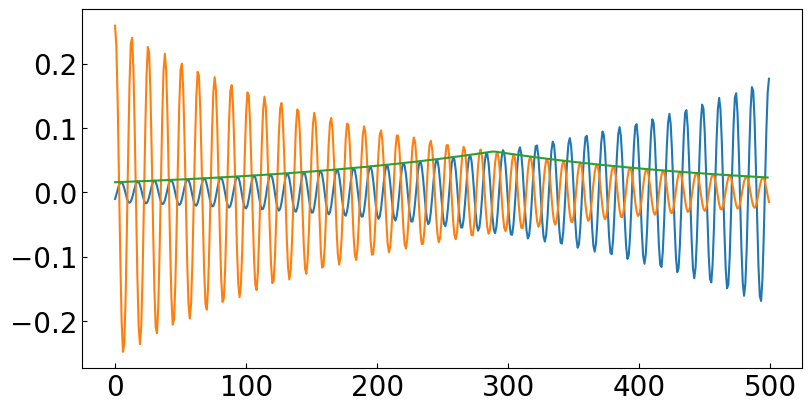

In [ ]:
# utr simulation
id = 4
amp_id = 7
sample_rate = 2e-9
ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
x = np.linspace(0, 499, 500)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
tr_waveform_if = (y_env*np.cos(2*np.pi* ph_if[id]*(x*1e-9)))[::-1]*tr_amp[amp_id] * abs_rate[amp_id]
tr_waveform = (y_env)[::-1]*tr_amp[amp_id]
tr_waveform_abs = tr_waveform * abs_rate[amp_id] ## abs limit
fig, ax = plt.subplots(figsize=(8,4),constrained_layout=True)
utr_waveform_if = (y_env*np.cos(2*np.pi* ph_if[id]*(x*1e-9)))*tr_amp[amp_id] 
utr_waveform = (y_env)*tr_amp[amp_id]

ene_org = 0
for t in range(int(len(x)/sample_rate*1e-9)+1):
    y = utr_waveform[2*t]
    ene_org = ene_org + (y**2)*sample_rate

ys = []
ene_abs = 0
for t in range(int(len(x)/sample_rate*1e-9)+1):
    if tr_waveform_abs[2*t]<utr_waveform[2*t]:
        y = tr_waveform_abs[2*t]
        ys.append(y)
    else:
        y = utr_waveform[2*t]
        ys.append(y)
    ene_abs = ene_abs + (y**2)*sample_rate

# plt.plot(x, tr_waveform)
plt.plot(x, tr_waveform_if)
plt.plot(x, utr_waveform_if)
plt.plot(np.linspace(0, 498, 250), ys)
print(ene_org, ene_abs, ene_abs/ene_org*1e2)

In [ ]:
sim_utr_rate = [15.23, 14.805, 14.14, 13.47, 12.78, 11.89, 11.33, 10.87]